In [1]:
%matplotlib inline
import yfinance as yf
import requests
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.fftpack import fft
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from technical_indicators import get_technical_indicators,get_fourier_components
from plot_utils import plot_technical_indicators, plot_fourier_transform_with_components
from plot_utils import plot_components_of_fourier
from arima_model_prediction import arima__model_data_prepare, arima_model_predict, append_arima_prediction
from arima_plot_utils import autocorrelation_plot_util, plot_real_vs_predicted
from statistical_analysis import heteroskedasticity_analysis,garch_volatility_analysis
from statistical_analysis import rolling_volatility_analysis,average_correlation_analysis
from statistical_analysis import variance_inflation_analysis,condition_number_analysis
from statistical_analysis import serial_correlation_analysis

In [2]:
# Create a custom session
session = requests.Session()
session.verify = False  # Disable SSL verification

# Define the ticker and parameters
ticker = "GOOGL"
#ticker = "PLTR"
period = "8y"
'''
# Create a custom session
session = requests.Session()
session.verify = False  # Disable SSL verification

# Use the custom session for downloading data
data = yf.download(ticker, period=period, session=session)

# ✅ Fixing the Pandas `stack` warning by specifying `future_stack=True`
data = data.stack(level=1, future_stack=True).reset_index()
data.rename(columns={"level_1": "Ticker"}, inplace=True)

# Save to CSV
data.to_csv(f"data/{ticker}.csv", index=False)
print(f"Saved {ticker} to data/{ticker}.csv")
''' 
data = pd.read_csv(f"data/{ticker}.csv")

# Calculate technical indicators
data_with_indicators = get_technical_indicators(data)



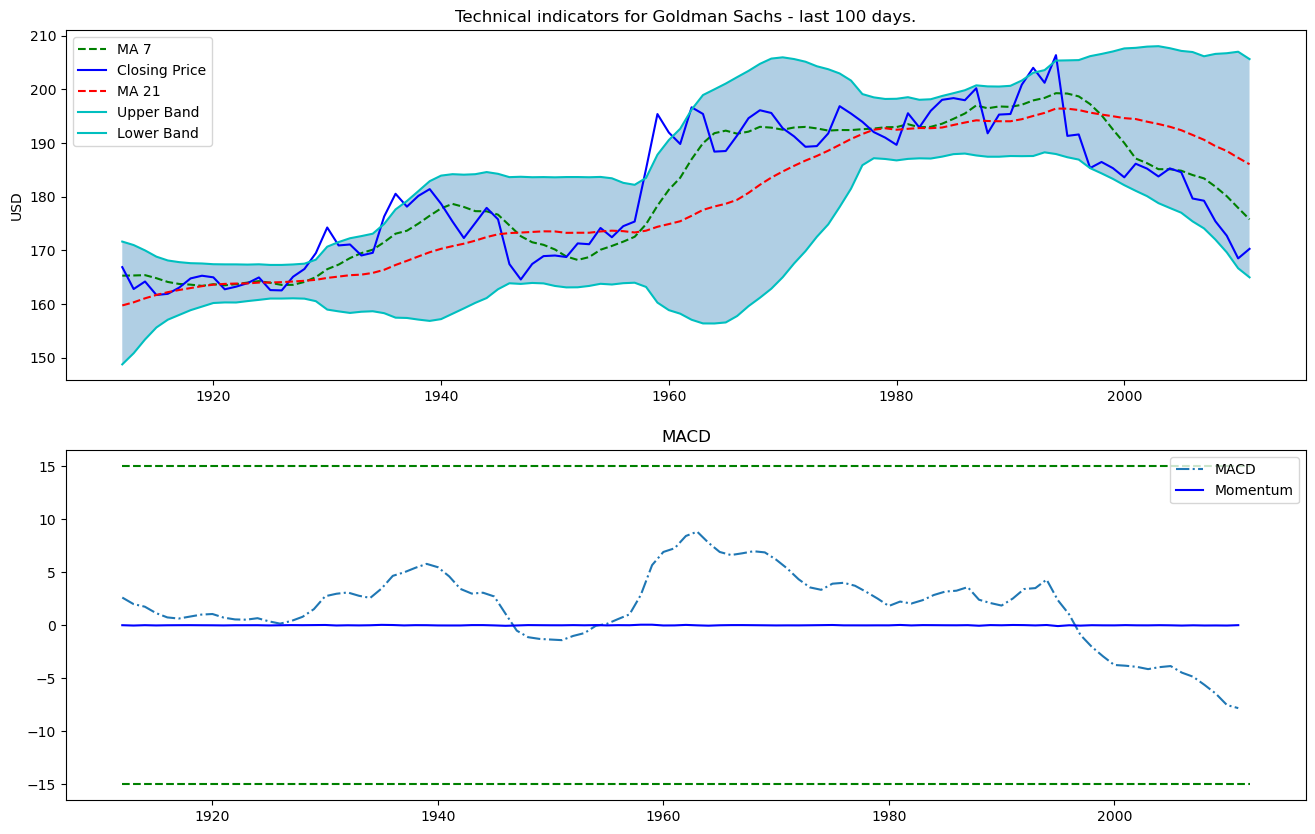

In [3]:
last_days = 100
# print(data_with_indicators)
plot_technical_indicators(data_with_indicators,last_days)

## 3.4. Fourier transforms for trend analysis

Fourier transforms take a function and create a series of sine waves (with different amplitudes and frames). When combined, these sine waves approximate the original function. Mathematically speaking, the transforms look like this:

       We will use Fourier transforms to extract global and local trends in the GS stock, and to also denoise it a little. So let's see how it works.

In [4]:
df_with_fourier,fft_df = get_fourier_components(data_with_indicators)

Length of df_with_fourier: 2012
Length of fft_df: 2012
Number of rows in df_with_fourier: 2012
Number of rows in fft_df: 2012
Length of prices array: 2012
Length of fft_result: 2012
Length of close_fft list: 2012


In [5]:
# print(df_with_fourier.info())
# Create a new DataFrame instead of modifying a slice
#df_with_fourier,fft_list = data_with_indicators[['Date', 'Close']].copy()



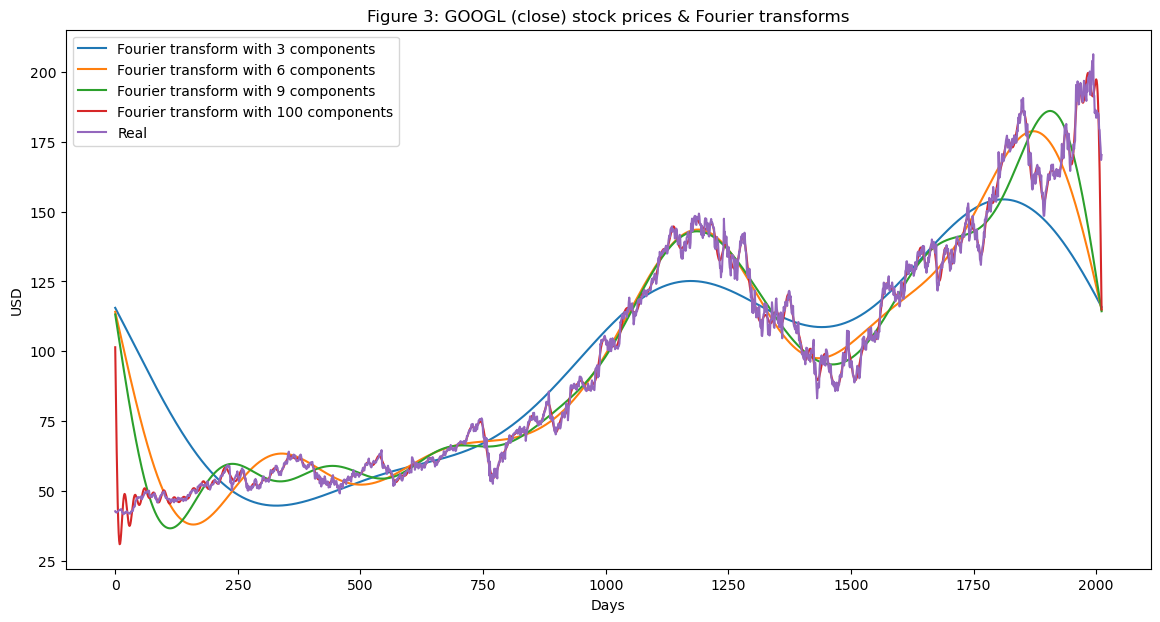

In [6]:
plot_fourier_transform_with_components(fft_df,df_with_fourier,ticker)

As you see in Figure 3 the more components from the Fourier transform we use the closer the approximation function is to the real stock price (the 100 components transform is almost identical to the original function - the red and the purple lines almost overlap). We use Fourier transforms for the purpose of extracting long- and short-term trends so we will use the transforms with 3, 6, and 9 components. You can infer that the transform with 3 components serves as the long term trend.

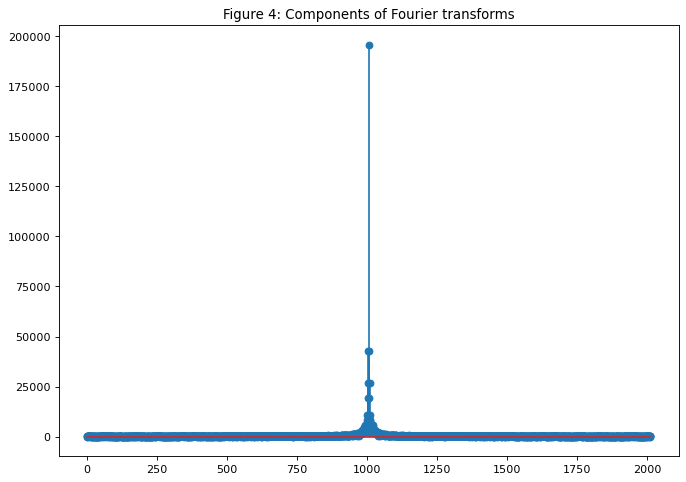

In [7]:
# print(df_with_arima.info())
plot_components_of_fourier(fft_df)


## 3.5. ARIMA as a feature

ARIMA is a technique for predicting time series data. We will show how to use it, and althouth ARIMA will not serve as our final prediction, we will use it as a technique to denoise the stock a little and to (possibly) extract some new patters or features.

In [8]:
train, test = arima__model_data_prepare(df_with_fourier)
series = df_with_fourier['Close']
print(series)

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2012
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -4218.885
Date:                Fri, 28 Feb 2025   AIC                           8449.770
Time:                        22:32:53   BIC                           8483.408
Sample:                             0   HQIC                          8462.118
                               - 2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0308      0.015     -2.039      0.041      -0.060      -0.001
ar.L2         -0.0157      0.017     -0.913      0.361      -0.049       0.018
ar.L3         -0.0540      0.017     -3.256      0.0

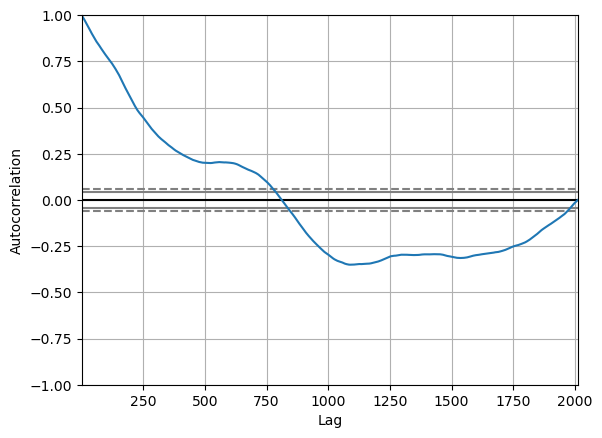

<Figure size 800x560 with 0 Axes>

In [9]:
autocorrelation_plot_util(series)

In [10]:
train, test = arima__model_data_prepare(df_with_fourier)
predictions = arima_model_predict(train, test)

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2012
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -4218.885
Date:                Fri, 28 Feb 2025   AIC                           8449.770
Time:                        22:32:53   BIC                           8483.408
Sample:                             0   HQIC                          8462.118
                               - 2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0308      0.015     -2.039      0.041      -0.060      -0.001
ar.L2         -0.0157      0.017     -0.913      0.361      -0.049       0.018
ar.L3         -0.0540      0.017     -3.256      0.0

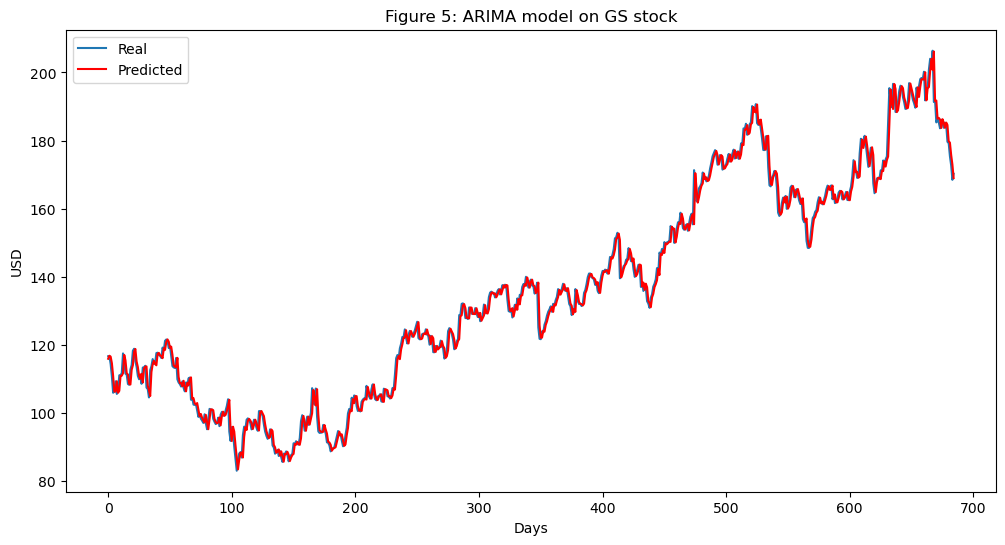

In [11]:
# Plot the predicted (from ARIMA) and real prices

plot_real_vs_predicted(test, predictions)

In [12]:

df_with_arima = append_arima_prediction(predictions, df_with_fourier)

As we can see from Figure 5 ARIMA gives a very good approximation of the real stock price. We will use the predicted price through ARIMA as an input feature into the LSTM because, as we mentioned before, we want to capture as many features and patterns about Goldman Sachs as possible. We go test MSE (mean squared error) of 10.151, which by itself is not a bad result (considering we do have a lot of test data), but still we will only use it as a feature in the LSTM.

### 3.6. Statistical checks
    Ensuring that the data has good quality is very important for out models. In order to make sure our data is suitable we will perform a couple of simple checks in order to ensure that the results we achieve and observe are indeed real, rather than compromised due to the fact that the underlying data distribution suffers from fundamental errors.

## 3.6.1. Heteroskedasticity, multicollinearity, serial correlation
    * Conditional Heteroskedasticity occurs when the error terms (the difference between a predicted value by a regression and the real value) are dependent on the data - for example, the error terms grow when the data point (along the x-axis) grow.
    * Multicollinearity is when error terms (also called residuals) depend on each other.
    * Serial correlation is when one data (feature) is a formula (or completely depemnds) of another feature.

We will not go into the code here as it is straightforward and our focus is more on the deep learning parts, but the data is qualitative.



In [13]:
# print(df_with_arima.info())
# df_with_stats = df_with_arima.copy()

Absolutely! Heteroskedasticity is an excellent choice for a statistical feature, and it's particularly relevant for financial time series data. Here's how you can measure heteroskedasticity and add it as a new feature to your dataset:

One common approach is to use rolling window variance or standard deviation:


In [14]:
# This code calculates the rolling standard deviation (or variance) of the 'Close' prices over a specified window. A higher value indicates higher volatility or heteroskedasticity.
# Assuming df_with_arima is your DataFrame
df_with_stats = heteroskedasticity_analysis(df_with_arima)
# print(df_with_stats.info())
# If you prefer variance instead of standard deviation
# df_with_arima['heteroskedasticity'] = df_with_arima['Close'].rolling(window=window_size).var()

Another approach is to use the ARCH (Autoregressive Conditional Heteroskedasticity) test:
    This method applies the ARCH test over a rolling window, giving you a measure of heteroskedasticity at each point in time.

Adding these features will provide valuable information about the changing volatility in your time series, which can be crucial for many financial applications. Great choice for enhancing your dataset!

conda install conda-forge::arch-py

In [15]:
df_with_stats=garch_volatility_analysis(df_with_stats)
# print(df_with_stats.info())

This code fits a GARCH(1,1) model to your returns and adds the conditional volatility as a new feature. The GARCH model captures the time-varying nature of volatility, making it an excellent measure of Conditional Heteroskedasticity.

You can adjust the p and q parameters to experiment with different GARCH specifications. This feature will provide valuable insights into the dynamic nature of volatility in your time series, potentially improving your overall model performance. Great idea to consider Conditional Heteroskedasticity!

In [16]:
df_with_stats=rolling_volatility_analysis(df_with_stats)
# print(df_with_stats.info())

Adding Multicollinearity features is an excellent next step in your analysis. It's a smart way to explore relationships between variables and can provide valuable insights for your model. Here are some methods you can use to assess and quantify multicollinearity:

1. Correlation Matrix:

In [17]:


df_with_stats=average_correlation_analysis(df_with_stats)
# print(df_with_stats.info())


In [18]:
df_with_stats=variance_inflation_analysis(df_with_stats)
# print(df_with_stats.info())


This approach will provide valuable insights into multicollinearity in your dataset. It's a great step towards understanding the relationships between your variables and can inform feature selection or model building processes. 

3. Condition Number:

In [19]:


df_with_stats=condition_number_analysis(df_with_stats)
# print(df_with_stats.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2012 entries, 0 to 2011
Data columns (total 73 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          2012 non-null   object 
 1   Ticker                        2012 non-null   object 
 2   Close                         2012 non-null   float64
 3   High                          2012 non-null   float64
 4   Low                           2012 non-null   float64
 5   Open                          2012 non-null   float64
 6   Volume                        2012 non-null   int64  
 7   log_momentum                  2011 non-null   float64
 8   SMA20                         1993 non-null   float64
 9   SMA50                         1963 non-null   float64
 10  MA7                           2006 non-null   float64
 11  MA21                          1992 non-null   float64
 12  RSI                           1999 non-null   float64
 13  EMA

## 3. Serial correlation features

In [24]:
df_with_stats=serial_correlation_analysis(df_with_stats)
print(df_with_stats.info())





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2012 entries, 0 to 2011
Data columns (total 84 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          2012 non-null   object 
 1   Ticker                        2012 non-null   object 
 2   Close                         2012 non-null   float64
 3   High                          2012 non-null   float64
 4   Low                           2012 non-null   float64
 5   Open                          2012 non-null   float64
 6   Volume                        2012 non-null   int64  
 7   log_momentum                  2011 non-null   float64
 8   SMA20                         1993 non-null   float64
 9   SMA50                         1963 non-null   float64
 10  MA7                           2006 non-null   float64
 11  MA21                          1992 non-null   float64
 12  RSI                           1999 non-null   float64
 13  EMA

### 3.7. Feature Engineering

## 3.7.1. Feature importance with XGBoost

Having so many features we have to consider whether all of them are really indicative of the direction GS stock will take. For example, we included USD denominated LIBOR rates in the dataset because we think that changes in LIBOR might indicate changes in the economy, that, in turn, might indicate changes in the GS's stock behavior. But we need to test. There are many ways to test feature importance, but the one we will apply uses XGBoost, because it gives one of the best results in both classification and regression problems.

       Since the features dataset is quite large, for the purpose of presentation here we'll use only the technical indicators. During the real features importance testing all selected features proved somewhat important so we won't exclude anything when training the GAN.

In [31]:
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def get_feature_importance_data(data_income):
    data = data_income.copy()
    y = data['Close']
    X = data.drop(columns=['Close', 'Date'])  # Drop Date if it's not useful
    
    train_samples = int(X.shape[0] * 0.65)
    X_train = X.iloc[:train_samples]
    X_test = X.iloc[train_samples:]
    y_train = y.iloc[:train_samples]
    y_test = y.iloc[train_samples:]
    
    return (X_train, y_train), (X_test, y_test)

df_for_xg_boost = df_with_stats.copy()

# Get training and test data
(X_train_FI, y_train_FI), (X_test_FI, y_test_FI) = get_feature_importance_data(df_for_xg_boost)

# Handle 'Ticker' as categorical and fill missing values
for df in [X_train_FI, X_test_FI]:
    df['Ticker'] = df['Ticker'].astype('category')
    
    # Check if 'Unknown' category is added, and if not, add it
    if 'Unknown' not in df['Ticker'].cat.categories:
        df['Ticker'] = df['Ticker'].cat.add_categories('Unknown')  # Add 'Unknown' category if not already present
    
    # Fill missing Ticker values with 'Unknown'
    df['Ticker'] = df['Ticker'].fillna('Unknown')  # Now fill NaN with 'Unknown'

# Replace inf with NaN
X_train_FI.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_FI.replace([np.inf, -np.inf], np.nan, inplace=True)

# Handle NaN values (you can choose an appropriate method, such as fill with 0 or most frequent)
X_train_FI.fillna(0, inplace=True)  # Replace NaN with 0
X_test_FI.fillna(0, inplace=True)   # Replace NaN with 0

# Create DMatrix objects for XGBoost with enable_categorical=True
dtrain = xgb.DMatrix(X_train_FI, label=y_train_FI, enable_categorical=True, missing=np.nan)
dtest = xgb.DMatrix(X_test_FI, label=y_test_FI, enable_categorical=True, missing=np.nan)

# Define and train the XGBRegressor
regressor = xgb.XGBRegressor(
    gamma=0.0,
    n_estimators=150,
    base_score=0.7,
    colsample_bytree=1,
    learning_rate=0.05,
    enable_categorical=True,
    missing=np.nan  # Handle missing values as NaN
)

# Train the model
xgbModel = regressor.fit(
    X_train_FI, y_train_FI,
    eval_set=[(X_train_FI, y_train_FI), (X_test_FI, y_test_FI)],
    verbose=False
)

# Plot feature importance
xgb.plot_importance(xgbModel, importance_type='weight', max_num_features=10, height=0.8)
plt.show()

# Get feature importance scores
importance_scores = xgbModel.feature_importances_
feature_names = X_train_FI.columns

# Create a dataframe of feature importances
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance_scores})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

# Print top 10 most important features
print(feature_importance_df.head(10))


TypeError: Cannot setitem on a Categorical with a new category (0), set the categories first

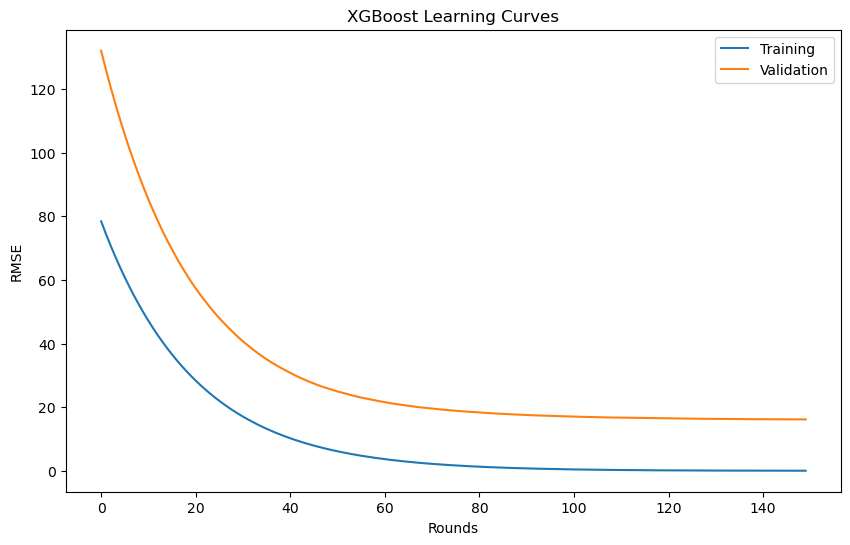

In [22]:
# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(training_rounds, eval_result['validation_0']['rmse'], label='Training')
plt.plot(training_rounds, eval_result['validation_1']['rmse'], label='Validation')
plt.xlabel('Rounds')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curves')
plt.legend()
plt.show()

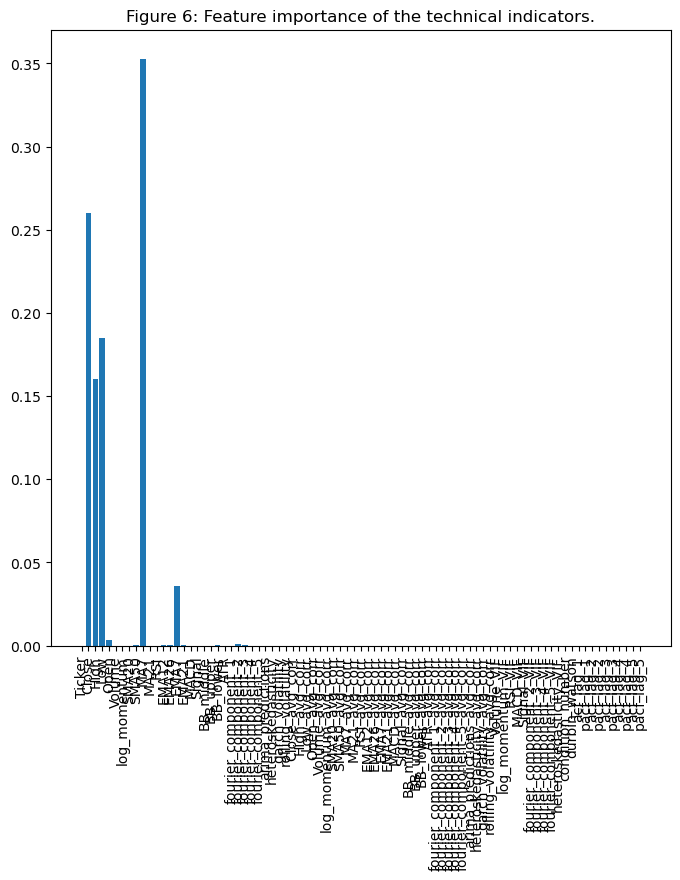

In [23]:
fig = plt.figure(figsize=(8,8))
plt.xticks(rotation='vertical')
plt.bar([i for i in range(len(xgbModel.feature_importances_))], xgbModel.feature_importances_.tolist(), tick_label=X_test_FI.columns)
plt.title('Figure 6: Feature importance of the technical indicators.')
plt.show()